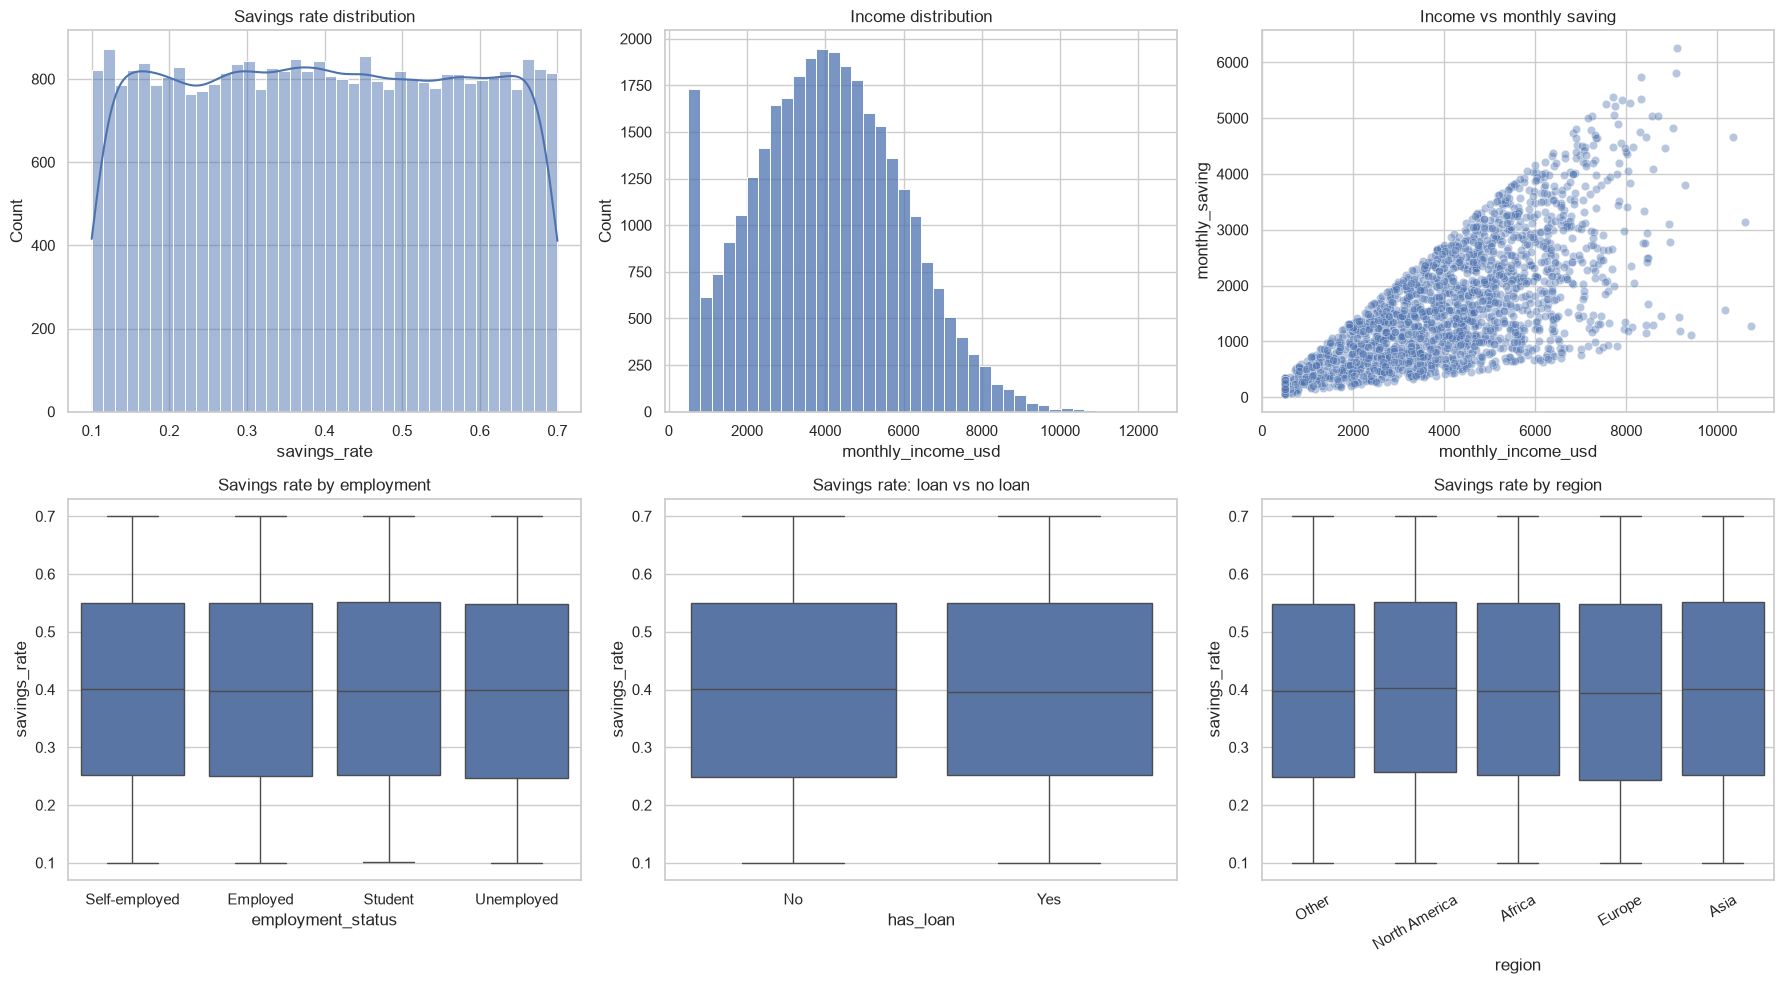

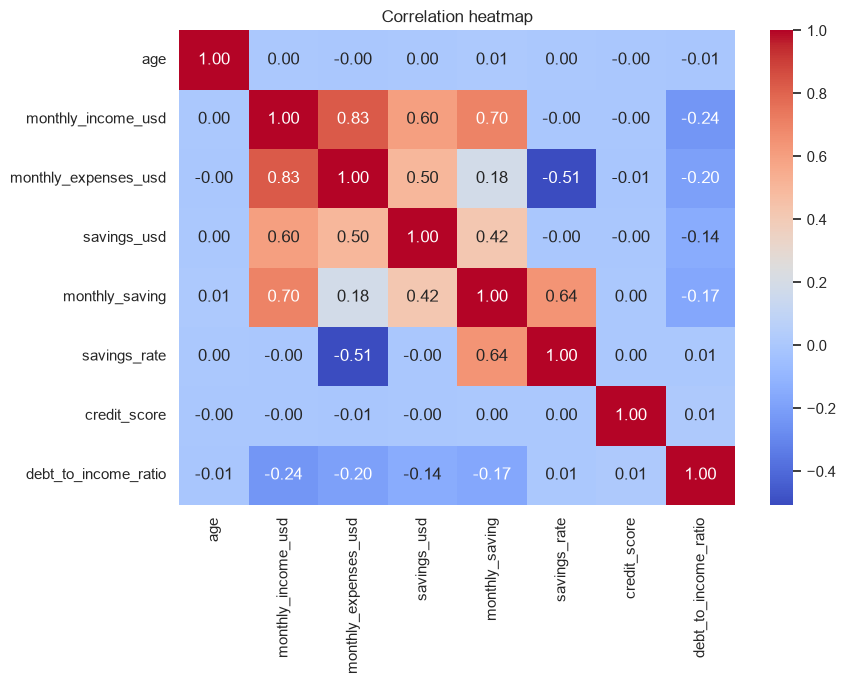

Pearson income vs saving: r=0.702, p=0
t-test savings rate (loan vs no loan): t=-0.35, p=0.724, means 0.399 vs 0.400
ANOVA savings rate across regions: F=1.72, p=0.143
{'Current plan': '60.1%', 'Save more': '66.7%', 'Save more + invest': '88.7%'}
Paired t-test scenario 3 vs 1: t=286.5, p=0


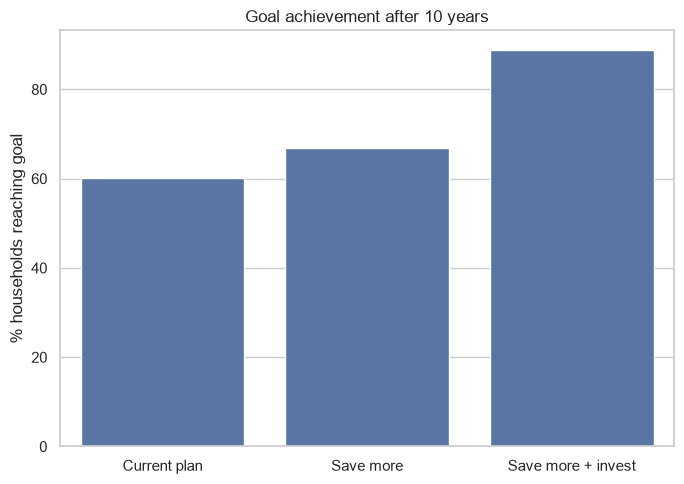

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

os.makedirs("../figures", exist_ok=True)
sns.set_theme(style="whitegrid")

# ---------- Load cleaned data (made by Block 1) ----------
df_clean = pd.read_csv("../personal_finance_clean.csv")

# ---------- Simulator functions ----------
def future_value(start, monthly, annual_rate, months):
    r = annual_rate / 12
    months = np.asarray(months, dtype=float)
    if r == 0:
        return start + monthly * months
    growth = (1 + r) ** months
    return start * growth + monthly * (growth - 1) / r

def real_value(nominal, inflation, months):
    return nominal / (1 + inflation) ** (np.asarray(months, dtype=float) / 12)

def scenario_values(start, income, expenses, extra_pct, invest_return_pct,
                    inflation_pct, months, bank_rate_pct=3.0):
    saving = income - expenses
    extra = income * extra_pct / 100
    s1 = future_value(start, saving, bank_rate_pct / 100, months)
    s2 = future_value(start, saving + extra, bank_rate_pct / 100, months)
    s3 = future_value(start, saving + extra, invest_return_pct / 100, months)
    infl = inflation_pct / 100
    return tuple(real_value(s, infl, months) for s in (s1, s2, s3))

# ---------- Charts ----------
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(df_clean["savings_rate"], bins=40, kde=True, ax=ax[0, 0]); ax[0, 0].set_title("Savings rate distribution")
sns.histplot(df_clean["monthly_income_usd"], bins=40, ax=ax[0, 1]); ax[0, 1].set_title("Income distribution")
sns.scatterplot(data=df_clean.sample(2000, random_state=1), x="monthly_income_usd", y="monthly_saving", alpha=.4, ax=ax[0, 2]); ax[0, 2].set_title("Income vs monthly saving")
sns.boxplot(data=df_clean, x="employment_status", y="savings_rate", ax=ax[1, 0]); ax[1, 0].set_title("Savings rate by employment")
sns.boxplot(data=df_clean, x="has_loan", y="savings_rate", ax=ax[1, 1]); ax[1, 1].set_title("Savings rate: loan vs no loan")
sns.boxplot(data=df_clean, x="region", y="savings_rate", ax=ax[1, 2]); ax[1, 2].set_title("Savings rate by region"); ax[1, 2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig("../figures/eda_overview.png", dpi=150); plt.show()

num_cols = ["age", "monthly_income_usd", "monthly_expenses_usd", "savings_usd",
            "monthly_saving", "savings_rate", "credit_score", "debt_to_income_ratio"]
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap"); plt.tight_layout()
plt.savefig("../figures/correlation.png", dpi=150); plt.show()

# ---------- Statistical tests ----------
r, p = stats.pearsonr(df_clean["monthly_income_usd"], df_clean["monthly_saving"])
print(f"Pearson income vs saving: r={r:.3f}, p={p:.3g}")

yes = df_clean.loc[df_clean.has_loan == "Yes", "savings_rate"]
no = df_clean.loc[df_clean.has_loan == "No", "savings_rate"]
t, p = stats.ttest_ind(yes, no, equal_var=False)
print(f"t-test savings rate (loan vs no loan): t={t:.2f}, p={p:.3g}, means {yes.mean():.3f} vs {no.mean():.3f}")

f, p = stats.f_oneway(*[g["savings_rate"].values for _, g in df_clean.groupby("region")])
print(f"ANOVA savings rate across regions: F={f:.2f}, p={p:.3g}")

# ---------- Run the 3 scenarios on every household ----------
YEARS, EXTRA, RET, INFL = 10, 10, 10, 5
s1, s2, s3 = scenario_values(df_clean["savings_usd"].values,
                             df_clean["monthly_income_usd"].values,
                             df_clean["monthly_expenses_usd"].values,
                             EXTRA, RET, INFL, YEARS * 12)
df_clean["s1"], df_clean["s2"], df_clean["s3"] = s1, s2, s3

hit = {name: (df_clean[col] >= df_clean["goal_usd"]).mean() * 100
       for name, col in [("Current plan", "s1"), ("Save more", "s2"), ("Save more + invest", "s3")]}
print({k: f"{v:.1f}%" for k, v in hit.items()})

t, p = stats.ttest_rel(df_clean["s3"], df_clean["s1"])
print(f"Paired t-test scenario 3 vs 1: t={t:.1f}, p={p:.3g}")

plt.figure(figsize=(7, 5))
sns.barplot(x=list(hit.keys()), y=list(hit.values()))
plt.ylabel("% households reaching goal"); plt.title(f"Goal achievement after {YEARS} years")
plt.tight_layout(); plt.savefig("../figures/scenario_results.png", dpi=150); plt.show()

In [8]:
df_clean.to_csv("../personal_finance_clean.csv", index=False)

In [7]:
df_clean["monthly_saving"] = df_clean["monthly_income_usd"] - df_clean["monthly_expenses_usd"]
df_clean["savings_rate"] = df_clean["monthly_saving"] / df_clean["monthly_income_usd"]
df_clean["goal_usd"] = df_clean["monthly_expenses_usd"] * 12 * 10   # my assumption: 10 years of expenses

df_clean[["monthly_income_usd", "monthly_expenses_usd", "monthly_saving", "savings_rate", "goal_usd"]].describe()

,monthly_income_usd,monthly_expenses_usd,monthly_saving,savings_rate,goal_usd
count,32424.000000,32424.000000,32424.000000,32424.000000,3.242400e+04
mean,4027.863185,2419.444709,1608.418476,0.399518,2.903334e+05
std,1916.773353,1388.893084,1090.052661,0.173485,1.666672e+05
min,500.000000,150.010000,50.560000,0.100012,1.800120e+04
25%,2657.795000,1397.497500,752.550000,0.250281,1.676997e+05
50%,3997.740000,2219.575000,1385.815000,0.398654,2.663490e+05
75%,5351.607500,3254.037500,2260.682500,0.549910,3.904845e+05
max,12404.050000,10082.710000,7158.310000,0.699994,1.209925e+06


In [6]:
# Work on a copy so the raw data stays untouched
df_clean = df.copy()

# 1. Empty loan_type means no loan
df_clean["loan_type"] = df_clean["loan_type"].fillna("None")

# 2. Convert text date to a real date
df_clean["record_date"] = pd.to_datetime(df_clean["record_date"])

# 3. Remove duplicate rows (if any)
df_clean = df_clean.drop_duplicates()

df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  32424 non-null  str           
 1   age                      32424 non-null  int64         
 2   gender                   32424 non-null  str           
 3   education_level          32424 non-null  str           
 4   employment_status        32424 non-null  str           
 5   job_title                32424 non-null  str           
 6   monthly_income_usd       32424 non-null  float64       
 7   monthly_expenses_usd     32424 non-null  float64       
 8   savings_usd              32424 non-null  float64       
 9   has_loan                 32424 non-null  str           
 10  loan_type                32424 non-null  str           
 11  loan_amount_usd          32424 non-null  float64       
 12  loan_term_months         32424 non-null  in

In [5]:
# Text columns: look for typos or odd categories
for col in ["gender", "education_level", "employment_status", "has_loan", "loan_type", "region"]:
    print(col, df[col].unique(), "\n")

gender <ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str 

education_level <ArrowStringArray>
['High School', 'PhD', 'Master', 'Bachelor', 'Other']
Length: 5, dtype: str 

employment_status <ArrowStringArray>
['Self-employed', 'Employed', 'Student', 'Unemployed']
Length: 4, dtype: str 

has_loan <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str 

loan_type <ArrowStringArray>
[nan, 'Education', 'Business', 'Car', 'Home']
Length: 5, dtype: str 

region <ArrowStringArray>
['Other', 'North America', 'Africa', 'Europe', 'Asia']
Length: 5, dtype: str 



In [4]:
# Impossible or suspicious values
print("Negative income:", (df["monthly_income_usd"] <= 0).sum())
print("Negative savings:", (df["savings_usd"] < 0).sum())
print("Expenses > income:", (df["monthly_expenses_usd"] > df["monthly_income_usd"]).sum())


Negative income: 0
Negative savings: 0
Expenses > income: 0


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_csv("../personal_finance_dataset.csv")

# First look
print("Rows, Columns:", df.shape)
print("\nColumn names:\n", list(df.columns))
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df.head()

Rows, Columns: (32424, 20)

Column names:
 ['user_id', 'age', 'gender', 'education_level', 'employment_status', 'job_title', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'has_loan', 'loan_type', 'loan_amount_usd', 'loan_term_months', 'monthly_emi_usd', 'loan_interest_rate_pct', 'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio', 'region', 'record_date']

Missing values:
 user_id                        0
age                            0
gender                         0
education_level                0
employment_status              0
job_title                      0
monthly_income_usd             0
monthly_expenses_usd           0
savings_usd                    0
has_loan                       0
loan_type                  19429
loan_amount_usd                0
loan_term_months               0
monthly_emi_usd                0
loan_interest_rate_pct         0
debt_to_income_ratio           0
credit_score                   0
savings_to_income_ratio        0
r

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  32424 non-null  str    
 1   age                      32424 non-null  int64  
 2   gender                   32424 non-null  str    
 3   education_level          32424 non-null  str    
 4   employment_status        32424 non-null  str    
 5   job_title                32424 non-null  str    
 6   monthly_income_usd       32424 non-null  float64
 7   monthly_expenses_usd     32424 non-null  float64
 8   savings_usd              32424 non-null  float64
 9   has_loan                 32424 non-null  str    
 10  loan_type                12995 non-null  str    
 11  loan_amount_usd          32424 non-null  float64
 12  loan_term_months         32424 non-null  int64  
 13  monthly_emi_usd          32424 non-null  float64
 14  loan_interest_rate_pct   32424 no

,age,monthly_income_usd,monthly_expenses_usd,savings_usd,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio
count,32424.000000,32424.000000,32424.000000,3.242400e+04,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000
mean,43.415865,4027.863185,2419.444709,2.437520e+05,100114.735992,58.500000,3092.992339,6.616332,1.194881,575.260424,5.045431
std,14.978246,1916.773353,1388.893084,1.915772e+05,152536.588635,104.865373,6478.939776,9.472964,3.761964,159.023227,2.851344
min,18.000000,500.000000,150.010000,6.359600e+02,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,0.100000
25%,30.000000,2657.795000,1397.497500,8.629155e+04,0.000000,0.000000,0.000000,0.000000,0.000000,437.000000,2.580000
50%,43.000000,3997.740000,2219.575000,2.017003e+05,0.000000,0.000000,0.000000,0.000000,0.000000,575.000000,5.040000
75%,56.000000,5351.607500,3254.037500,3.589662e+05,189499.070000,60.000000,3574.567500,13.140000,0.920000,714.000000,7.510000
max,69.000000,12404.050000,10082.710000,1.237774e+06,499954.750000,360.000000,47723.840000,30.000000,90.670000,850.000000,10.000000


In [3]:
# Is "loan_type" empty only when there is no loan?
print(df.groupby("has_loan")["loan_type"].apply(lambda s: s.isnull().sum()))

has_loan
No     19429
Yes        0
Name: loan_type, dtype: int64


In [9]:
# Impossible or suspicious values
print("Negative or zero income:", (df["monthly_income_usd"] <= 0).sum())
print("Negative savings:", (df["savings_usd"] < 0).sum())
print("Expenses > income:", (df["monthly_expenses_usd"] > df["monthly_income_usd"]).sum())

Negative or zero income: 0
Negative savings: 0
Expenses > income: 0


In [10]:
# Text columns: look for typos or odd categories
for col in ["gender", "education_level", "employment_status", "has_loan", "loan_type", "region"]:
    print(col, df[col].unique(), "\n")

gender <ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str 

education_level <ArrowStringArray>
['High School', 'PhD', 'Master', 'Bachelor', 'Other']
Length: 5, dtype: str 

employment_status <ArrowStringArray>
['Self-employed', 'Employed', 'Student', 'Unemployed']
Length: 4, dtype: str 

has_loan <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str 

loan_type <ArrowStringArray>
[nan, 'Education', 'Business', 'Car', 'Home']
Length: 5, dtype: str 

region <ArrowStringArray>
['Other', 'North America', 'Africa', 'Europe', 'Asia']
Length: 5, dtype: str 



In [12]:
df_clean = df.copy()
df_clean["loan_type"] = df_clean["loan_type"].fillna("None")      # empty = no loan
df_clean["record_date"] = pd.to_datetime(df_clean["record_date"])
df_clean = df_clean.drop_duplicates()

df_clean["monthly_saving"] = df_clean["monthly_income_usd"] - df_clean["monthly_expenses_usd"]
df_clean["savings_rate"] = df_clean["monthly_saving"] / df_clean["monthly_income_usd"]
df_clean["goal_usd"] = df_clean["monthly_expenses_usd"] * 12 * 10   # assumption: goal = 10 years of expenses

# checks for the report
for col in ["monthly_income_usd", "monthly_expenses_usd", "savings_usd"]:
    q1, q3 = df_clean[col].quantile([.25, .75]); iqr = q3 - q1
    print(col, "outliers:", ((df_clean[col] < q1-1.5*iqr) | (df_clean[col] > q3+1.5*iqr)).sum())
print("Expenses below EMI (loan holders):", ((df_clean.has_loan=="Yes") & (df_clean.monthly_expenses_usd < df_clean.monthly_emi_usd)).sum())

df_clean.to_csv("../personal_finance_clean.csv", index=False)
df_clean[["monthly_saving","savings_rate","goal_usd"]].describe()

monthly_income_usd outliers: 105
monthly_expenses_usd outliers: 476
savings_usd outliers: 448
Expenses below EMI (loan holders): 9650


,monthly_saving,savings_rate,goal_usd
count,32424.000000,32424.000000,3.242400e+04
mean,1608.418476,0.399518,2.903334e+05
std,1090.052661,0.173485,1.666672e+05
min,50.560000,0.100012,1.800120e+04
25%,752.550000,0.250281,1.676997e+05
50%,1385.815000,0.398654,2.663490e+05
75%,2260.682500,0.549910,3.904845e+05
max,7158.310000,0.699994,1.209925e+06
